# Experiment 9: Autoencoders for Image Denoising

This notebook explores and implements a Convolutional Autoencoder for image denoising with proper visualization and illustration.

## Do you need a dataset?
Yes. Autoencoders require image data. In this notebook we use a built-in dataset from TensorFlow (MNIST), so you do not need to manually download a CSV/image folder unless you want to try your own dataset.

## 1. Import Libraries

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_style('whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## 2. Load Dataset (MNIST)

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print('Train shape:', X_train.shape, y_train.shape)
print('Test shape :', X_test.shape, y_test.shape)

class_names = [str(i) for i in range(10)]

Train shape: (60000, 28, 28) (60000,)
Test shape : (10000, 28, 28) (10000,)


## 3. Preprocessing and Noise Injection

In [3]:
# Normalize images to [0, 1] and add channel dimension for CNN layers
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print('Normalized train shape:', X_train.shape)
print('Normalized test shape :', X_test.shape)

Normalized train shape: (60000, 28, 28, 1)
Normalized test shape : (10000, 28, 28, 1)


In [4]:
# Add Gaussian noise
noise_factor = 0.40

X_train_noisy = X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_noisy = X_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)

# Keep pixel values in valid image range
X_train_noisy = np.clip(X_train_noisy, 0.0, 1.0)
X_test_noisy = np.clip(X_test_noisy, 0.0, 1.0)

print('Noisy train min/max:', X_train_noisy.min(), X_train_noisy.max())
print('Noisy test min/max :', X_test_noisy.min(), X_test_noisy.max())

Noisy train min/max: 0.0 1.0
Noisy test min/max : 0.0 1.0


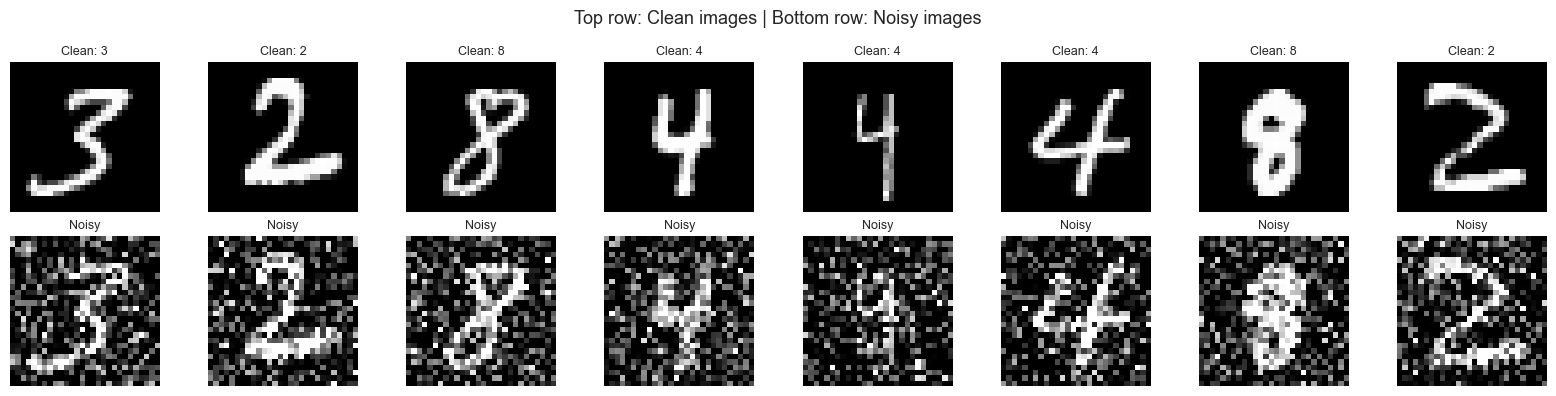

In [5]:
# Visualize clean vs noisy images
n = 8
idx = np.random.choice(len(X_train), n, replace=False)

plt.figure(figsize=(16, 4))
for i, idv in enumerate(idx):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_train[idv].squeeze(), cmap='gray')
    plt.title(f'Clean: {class_names[y_train[idv]]}', fontsize=9)
    plt.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(X_train_noisy[idv].squeeze(), cmap='gray')
    plt.title('Noisy', fontsize=9)
    plt.axis('off')

plt.suptitle('Top row: Clean images | Bottom row: Noisy images', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Build Convolutional Autoencoder

In [6]:
def build_autoencoder(input_shape=(28, 28, 1)):
    inputs = keras.Input(shape=input_shape, name='input_image')

    # Encoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same', name='encoded')(x)

    # Decoder
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    outputs = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='denoised_output')(x)

    autoencoder = keras.Model(inputs, outputs, name='conv_autoencoder')
    return autoencoder

autoencoder = build_autoencoder(input_shape=X_train.shape[1:])
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['mse'])
autoencoder.summary()

Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ denoised_output (Conv2D)        │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Optional model diagram
try:
    keras.utils.plot_model(autoencoder, show_shapes=True, show_layer_names=True, dpi=80)
except Exception as e:
    print('plot_model is optional and may require extra dependencies.')
    print('Reason:', e)

You must install pydot (`pip install pydot`) for `plot_model` to work.


## 5. Train the Autoencoder

In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

history = autoencoder.fit(
    X_train_noisy, X_train,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    shuffle=True,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - loss: 0.1429 - mse: 0.0260 - val_loss: 0.1009 - val_mse: 0.0125 - learning_rate: 0.0010
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 0.0965 - mse: 0.0112 - val_loss: 0.0945 - val_mse: 0.0105 - learning_rate: 0.0010
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 0.0925 - mse: 0.0099 - val_loss: 0.0919 - val_mse: 0.0096 - learning_rate: 0.0010
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - loss: 0.0905 - mse: 0.0093 - val_loss: 0.0905 - val_mse: 0.0091 - learning_rate: 0.0010
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - loss: 0.0892 - mse: 0.0089 - val_loss: 0.0894 - val_mse: 0.0088 - learning_rate: 0.0010
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - loss: 0.0883 - mse: 0.0086 - val_loss: 0.0886 - val_mse: 0.0085 - learning_rate: 0.0010
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - loss: 0.0875 - mse: 0.0083 - val_loss: 0.0879 - val_mse: 0.0083 - learning_rate:

## 6. Training Curves Visualization

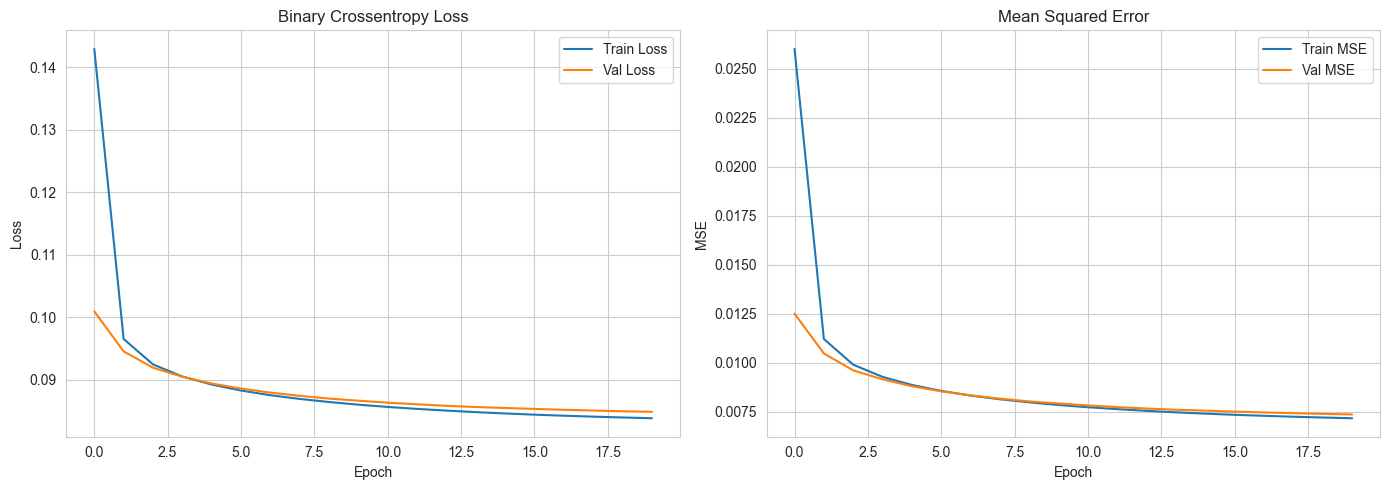

In [9]:
hist = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist['loss'], label='Train Loss')
axes[0].plot(hist['val_loss'], label='Val Loss')
axes[0].set_title('Binary Crossentropy Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(hist['mse'], label='Train MSE')
axes[1].plot(hist['val_mse'], label='Val MSE')
axes[1].set_title('Mean Squared Error')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Denoising Results

In [10]:
# Reconstruct denoised test images
X_test_denoised = autoencoder.predict(X_test_noisy, verbose=0)

# Evaluate reconstruction quality
recon_mse = np.mean((X_test - X_test_denoised) ** 2)
recon_mae = np.mean(np.abs(X_test - X_test_denoised))

print(f'Reconstruction MSE: {recon_mse:.6f}')
print(f'Reconstruction MAE: {recon_mae:.6f}')

Reconstruction MSE: 0.007167
Reconstruction MAE: 0.027595


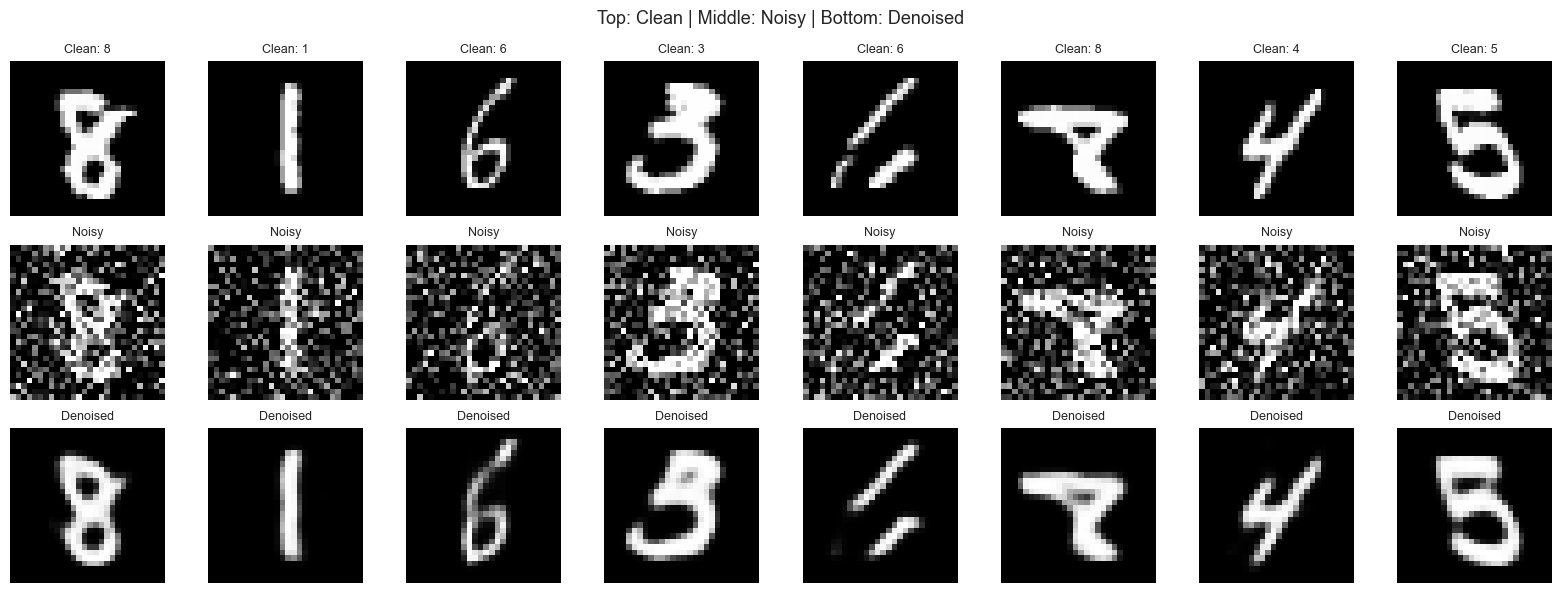

In [11]:
# Visualize clean, noisy, and denoised outputs
n = 8
idx = np.random.choice(len(X_test), n, replace=False)

plt.figure(figsize=(16, 6))
for i, idv in enumerate(idx):
    # Clean
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(X_test[idv].squeeze(), cmap='gray')
    plt.title(f'Clean: {class_names[y_test[idv]]}', fontsize=9)
    plt.axis('off')

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(X_test_noisy[idv].squeeze(), cmap='gray')
    plt.title('Noisy', fontsize=9)
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(X_test_denoised[idv].squeeze(), cmap='gray')
    plt.title('Denoised', fontsize=9)
    plt.axis('off')

plt.suptitle('Top: Clean | Middle: Noisy | Bottom: Denoised', fontsize=13)
plt.tight_layout()
plt.show()

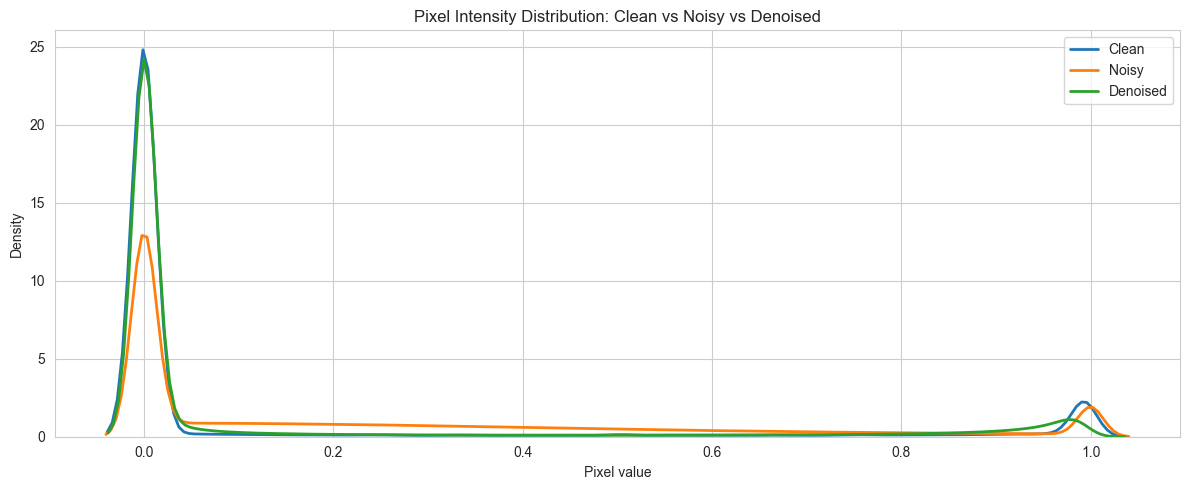

In [12]:
# Pixel intensity distribution comparison
clean_pixels = X_test.flatten()
noisy_pixels = X_test_noisy.flatten()
denoised_pixels = X_test_denoised.flatten()

plt.figure(figsize=(12, 5))
sns.kdeplot(clean_pixels, label='Clean', linewidth=2)
sns.kdeplot(noisy_pixels, label='Noisy', linewidth=2)
sns.kdeplot(denoised_pixels, label='Denoised', linewidth=2)
plt.title('Pixel Intensity Distribution: Clean vs Noisy vs Denoised')
plt.xlabel('Pixel value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Latent Space Illustration (Encoder Output)

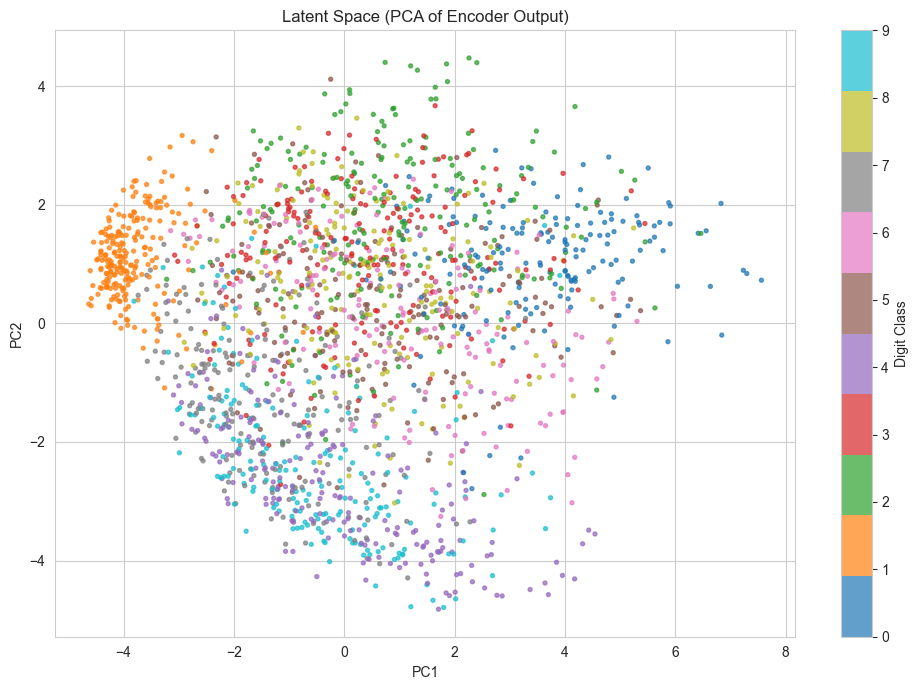

Explained variance by first 2 PCA components: 0.2109


In [13]:
# Build encoder model from the trained autoencoder
encoder = keras.Model(inputs=autoencoder.input, outputs=autoencoder.get_layer('encoded').output, name='encoder')

encoded_test = encoder.predict(X_test_noisy[:2000], verbose=0)
encoded_flat = encoded_test.reshape(len(encoded_test), -1)

# Reduce to 2D for visualization using PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=SEED)
encoded_2d = pca.fit_transform(encoded_flat)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(encoded_2d[:, 0], encoded_2d[:, 1], c=y_test[:2000], cmap='tab10', s=8, alpha=0.7)
plt.title('Latent Space (PCA of Encoder Output)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Digit Class')
plt.tight_layout()
plt.show()

print('Explained variance by first 2 PCA components:', np.round(pca.explained_variance_ratio_.sum(), 4))

## 9. Conclusion

You implemented a convolutional autoencoder for denoising and evaluated it with visual and numeric checks.

### Key takeaways
- Autoencoders learn compressed representations and can reconstruct cleaner images from noisy input.
- Reconstruction quality can be assessed with MSE/MAE and side-by-side image comparisons.
- A dataset is required, but built-in datasets like MNIST are enough for learning and experiments.

### Optional extensions
- Try Fashion-MNIST or CIFAR-10.
- Increase/decrease noise_factor and compare outcomes.
- Use deeper encoder-decoder blocks for better denoising quality.